   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1               Yes         78         82   

C:\Users\gnana\AppData\Local\Temp\ipykernel_22628\3412121174.py:30: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


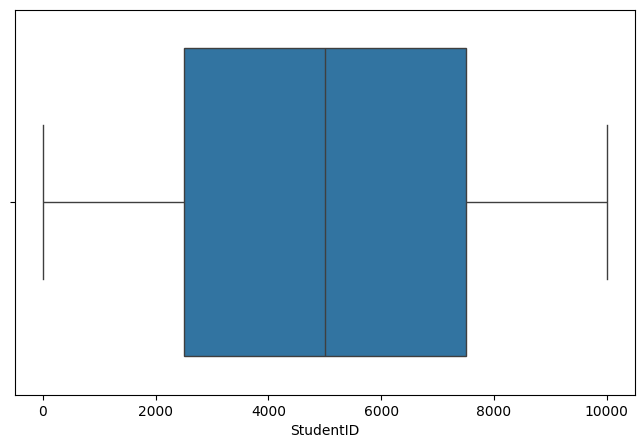

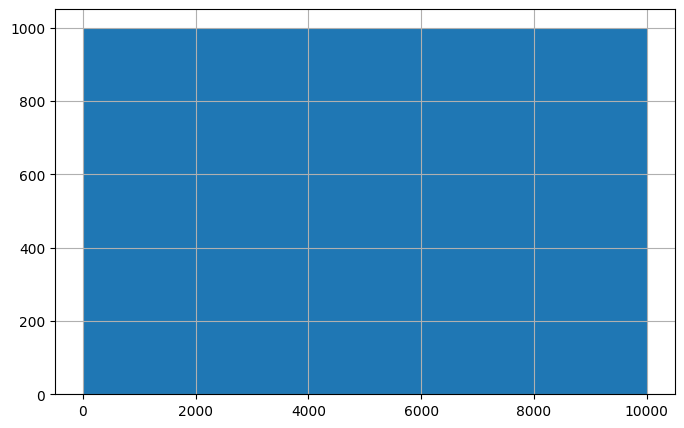

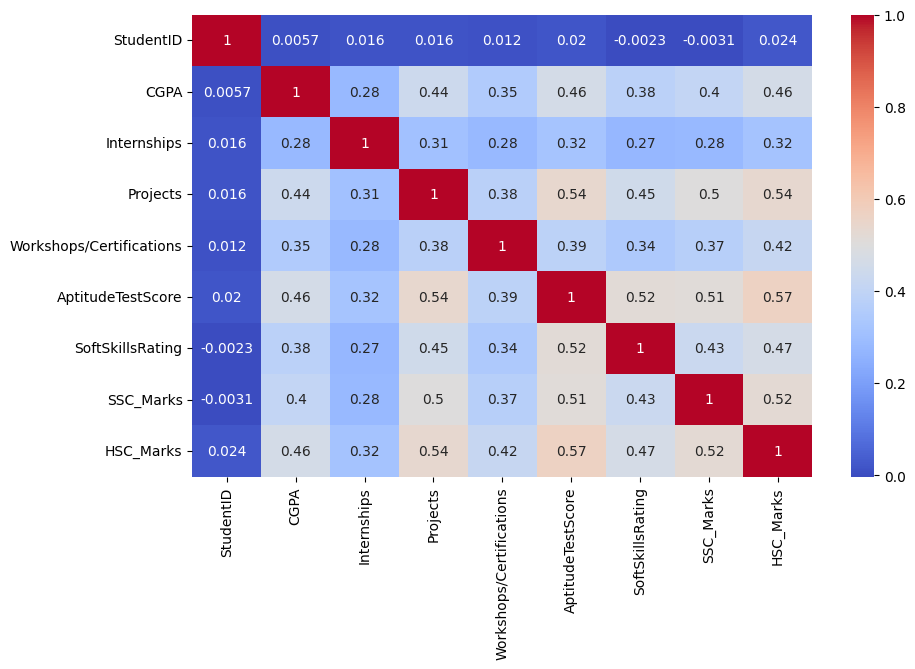

Target column: PlacementStatus
Accuracy: 0.7935
Prediction: ['NotPlaced']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("placementdata.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

# -----------------------------
# DO NOT convert all to datetime ❌
# Only keep data as it is
# -----------------------------

# Drop missing values
df = df.dropna()

# -----------------------------
# Convert numeric-like columns
# -----------------------------
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# -----------------------------
# Get numeric columns safely
# -----------------------------
numeric_df = df.select_dtypes(include=np.number)

if len(numeric_df.columns) > 0:
    numeric_column = numeric_df.columns[0]

    # Boxplot
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[numeric_column])
    plt.show()

    # Histogram
    plt.figure(figsize=(8,5))
    df[numeric_column].hist()
    plt.show()

    # Heatmap
    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.show()
else:
    print("No numeric columns available for plotting")

# -----------------------------
# Target column (last column)
# -----------------------------
target_column = df.columns[-1]
print("Target column:", target_column)

# -----------------------------
# Features & Target
# -----------------------------
X = df.drop(target_column, axis=1)
y = df[target_column]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# -----------------------------
# Scaling
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model Training
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# -----------------------------
# Sample Prediction
# -----------------------------
sample = X_test[0].reshape(1, -1)
print("Prediction:", model.predict(sample))